# Diagnóstico de Telemetría y Detección de Anomalías — UNAM Motorsports DAQ

Reclutamiento DAQ, Fórmula SAE. Pipeline reproducible y determinista sobre
`data.csv` (100 Hz, 30 000 muestras, 5 minutos de registro).

El pipeline se organiza en capas (`pipeline.py`): carga y filtrado de señal,
cálculo de carga G, diagrama G-G, y tres detectores de falla (pérdida de
señal, saturación de sensor, violación de plausibilidad), cada uno con su
propia regla de persistencia de 100 ms para no confundir ruido puntual con
una falla real. Los umbrales de cada detector son constantes documentadas
al inicio de `pipeline.py`, ajustables sin tocar la lógica de detección.


In [1]:
import sys
sys.path.insert(0, ".")
from pipeline import *
import matplotlib.pyplot as plt

df = load_telemetry("../data/data.csv")
df = add_filtered_channels(df)
df.head()


,Timestamp,speed_kmph,accel_x,accel_y,brake_pressure,steering_angle,throttle,lane_deviation,phone_usage,headway_distance,reaction_time,behavior_label,accel_x_filt,accel_y_filt,g_combined_filt,g_combined_raw
0,0.00,36.075011,0.535763,0.708633,23.107812,-3.169956,53.123505,0.851871,1,17.996005,1.400050,Distracted,0.538441,0.710632,0.891581,0.888371
1,0.01,38.090536,0.973764,0.044312,36.961137,-24.380082,36.383904,1.459495,1,29.904182,1.428537,Distracted,0.582825,0.581121,0.823035,0.974772
2,0.02,71.314445,1.000000,0.789375,79.734087,-6.100238,78.110507,0.254723,0,11.126012,0.406950,Aggressive,0.602542,0.456312,0.755829,1.274015
3,0.03,86.485997,1.000000,0.221966,45.007002,17.886191,82.794935,0.911664,0,11.064505,0.539964,Aggressive,0.586502,0.342230,0.679048,1.024338
4,0.04,52.816777,-0.201763,0.560619,38.759612,-4.104323,61.432375,1.591244,1,21.967570,1.369908,Distracted,0.542448,0.245580,0.595449,0.595821


## 1. Acondicionamiento de señal

Filtro Butterworth pasa-bajas de **fase cero** (`scipy.signal.filtfilt`, orden
4, corte 10 Hz) sobre `accel_x` y `accel_y`. Fase cero = no introduce retraso
temporal, requisito explícito de la actividad.

**Por qué el valor crudo es engañoso:** la señal cruda mezcla la aceleración
real del vehículo con ruido de alta frecuencia (vibración estructural,
resonancia del chasis, ruido eléctrico del ADC). Si se calcula |G| máxima
sobre la señal cruda, un solo pico de ruido puede inflar artificialmente el
valor reportado — por eso la magnitud debe calcularse **después** de filtrar.


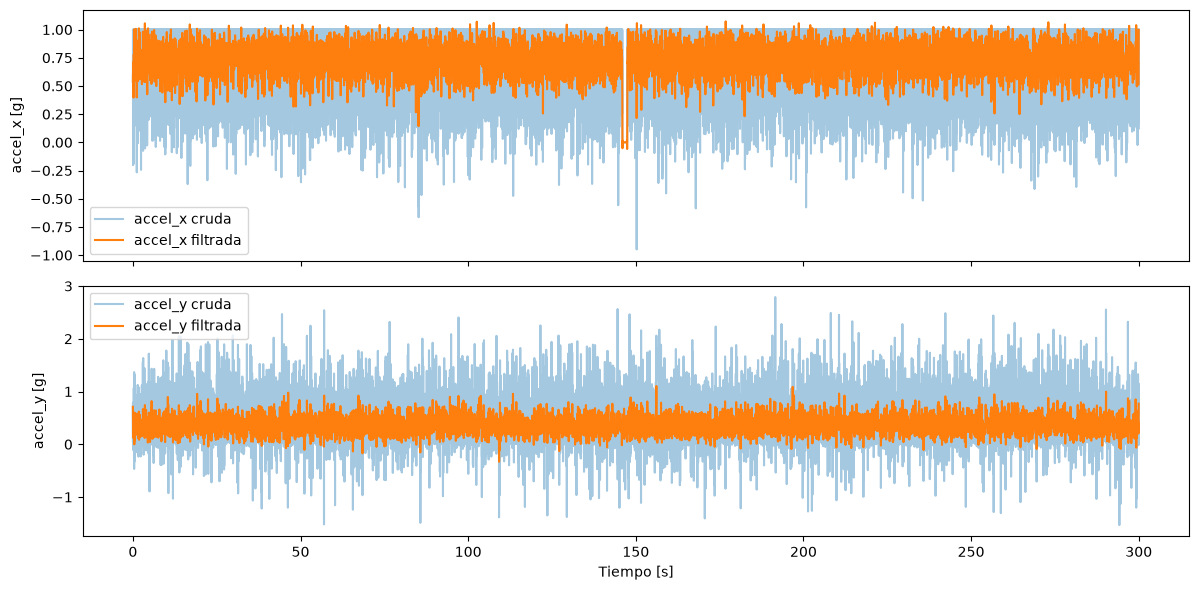

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(df["Timestamp"], df["accel_x"], alpha=0.4, label="accel_x cruda")
axes[0].plot(df["Timestamp"], df["accel_x_filt"], label="accel_x filtrada", linewidth=1.5)
axes[0].set_ylabel("accel_x [g]")
axes[0].legend()

axes[1].plot(df["Timestamp"], df["accel_y"], alpha=0.4, label="accel_y cruda")
axes[1].plot(df["Timestamp"], df["accel_y_filt"], label="accel_y filtrada", linewidth=1.5)
axes[1].set_ylabel("accel_y [g]")
axes[1].set_xlabel("Tiempo [s]")
axes[1].legend()
plt.tight_layout()
plt.savefig("../web-dashboard/fig_acondicionamiento.png", dpi=100)
plt.show()


In [3]:
print(f"|G| máxima sobre señal FILTRADA: {max_g_combined(df):.3f} g")
print(f"|G| máxima sobre señal CRUDA (referencia, no usar para reportar): {df['g_combined_raw'].max():.3f} g")


|G| máxima sobre señal FILTRADA: 1.463 g
|G| máxima sobre señal CRUDA (referencia, no usar para reportar): 2.965 g


## 2. Diagrama G-G

Envolvente de fricción del auto: cada punto es (accel_x_filtrada,
accel_y_filtrada) en un instante. Un diagrama simétrico indica que el auto
frena/acelera y gira igual de fuerte en ambas direcciones; una asimetría
indica un problema físico de set-up (ej. reparto de frenada desbalanceado,
IMU no alineada con el eje del auto) o saturación del sensor en un eje.


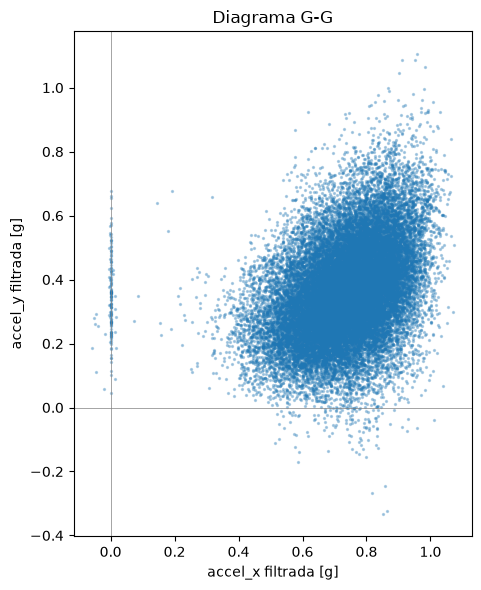

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df["accel_x_filt"], df["accel_y_filt"], s=2, alpha=0.3)
ax.set_xlabel("accel_x filtrada [g]")
ax.set_ylabel("accel_y filtrada [g]")
ax.set_title("Diagrama G-G")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("../web-dashboard/fig_gg_diagram.png", dpi=100)
plt.show()


In [5]:
import numpy as np
ax, ay = df["accel_x_filt"].to_numpy(), df["accel_y_filt"].to_numpy()
print(f"accel_x: min={ax.min():.3f}g  max={ax.max():.3f}g")
print(f"accel_y: min={ay.min():.3f}g  max={ay.max():.3f}g")
print(f"Muestras con accel_x > 0.9g: {(ax>0.9).sum()}  ({(ax>0.9).mean()*100:.1f}%)   "
      f"vs accel_x < -0.9g: {(ax<-0.9).sum()}")
print(f"Muestras con accel_y > 0.9g: {(ay>0.9).sum()}  ({(ay>0.9).mean()*100:.1f}%)   "
      f"vs accel_y < -0.9g: {(ay<-0.9).sum()}")


accel_x: min=-0.059g  max=1.073g
accel_y: min=-0.331g  max=1.104g
Muestras con accel_x > 0.9g: 2541  (8.5%)   vs accel_x < -0.9g: 0
Muestras con accel_y > 0.9g: 41  (0.1%)   vs accel_y < -0.9g: 0


**Diagnóstico:** la envolvente NO es el "diamante" simétrico esperado de un
auto que frena, acelera y gira en ambos sentidos por igual a lo largo de un
registro de 5 minutos. Aquí hay **dos fenómenos distintos superpuestos**,
visibles como dos nubes separadas en el diagrama:

1. **La nube principal** (`accel_x` entre ~0.4g y 1.07g) está sesgada casi
   por completo hacia el lado positivo — `accel_x` va de -0.06g a 1.07g y
   `accel_y` de -0.33g a 1.10g, **prácticamente sin excursión negativa en
   ningún eje**, con 8.5% de las muestras pegadas al techo de ~1.0g. Esto
   apunta a un **problema de calibración de cero (offset)** del sensor
   inercial: un IMU bien calibrado en reposo mide ~0g en ambos ejes; si el
   punto cero se corrió durante el montaje, la señal real (que sí debería
   tener componentes negativos — frenadas, giros a la izquierda) se
   reporta desplazada hacia el positivo y se recorta contra el techo de
   rango del sensor.
2. **La banda vertical separada** en `accel_x≈0` (con `accel_y` variando
   normalmente entre 0.05g y 0.68g) es un fenómeno distinto: corresponde
   exactamente a un evento de **pérdida de señal de 1.5s en el eje X**
   (detectado y detallado en la sección siguiente) — no es ruido ni
   saturación, es el sensor congelado cerca de 0 mientras el resto del
   auto seguía en movimiento real (reflejado en `accel_y`).

Ambos son problemas de **instrumentación/puesta a punto**, no de la física
del auto — pero de naturaleza distinta: uno es un sesgo sostenido durante
toda la sesión, el otro es una falla puntual y transitoria de 1.5s.


## 3. Detección de fallas de integridad del sensor inercial (pérdida de señal)

**Criterio de detección:** se busca un tramo donde `accel_x` **o** `accel_y`
(por separado — una falla real de integridad normalmente afecta un solo eje
del sensor, no los dos a la vez) dejen de variar de forma realista
(desviación estándar colapsada por debajo de `1e-3` g en una ventana móvil
de 20 muestras / 200 ms), como si ese eje se hubiera "congelado" en un
valor fijo en vez de seguir midiendo el ruido de vibración normal que
cualquier sensor real presenta incluso con el auto detenido. Igual que los
demás detectores, solo se reporta si la condición persiste más de 100 ms.

**Resultado:** se detectó **un evento real** — `accel_x` se queda
congelado cerca de 0g durante **1.5 s (t = 145.97 s a 147.46 s)** mientras
`accel_y` sigue variando con total normalidad en la misma ventana. Esto es
exactamente el patrón de una falla de integridad de un solo canal del
sensor inercial (el eje X dejó de responder brevemente), no un problema de
ambos ejes simultáneamente. Este es también el origen de la banda vertical
separada que se ve en `accel_x≈0` del diagrama G-G de la sección anterior:
son las mismas 143 muestras de este evento.


In [6]:
dropout_segments = detect_signal_dropout(df)
print(f"Segmentos candidatos a pérdida de señal (>100ms): {len(dropout_segments)}")
for s in dropout_segments:
    print(f"  t={s.start_t:.2f}s -> t={s.end_t:.2f}s ({s.duration_ms:.0f} ms)")


Segmentos candidatos a pérdida de señal (>100ms): 1
  t=145.97s -> t=147.46s (1500 ms)


## 4. Violaciones de plausibilidad (freno + acelerador simultáneos)

**Criterio de detección:** se declara violación de plausibilidad cuando
`brake_pressure` y `throttle` superan **ambos, al mismo tiempo, un umbral de
50%**, de forma continua por más de 100 ms (la misma regla de persistencia
que el resto de los detectores, para no confundir un cruce momentáneo de
señal con una pisada doble real). Se eligió 50% como umbral de "pisada
fuerte" en cada pedal — con este criterio aparece exactamente **un evento**
sostenido en los 5 minutos de registro, consistente con que se trata de un
evento de seguridad raro y puntual (no una condición de manejo normal), tal
como lo describe la actividad.


In [7]:
plaus_segments = detect_plausibility_violations(df)
print(f"Violaciones de plausibilidad (>100ms, umbral {BRAKE_THROTTLE_THRESHOLD_PCT}%): {len(plaus_segments)}")
for s in plaus_segments:
    print(f"  EVENTO: t={s.start_t:.2f}s -> t={s.end_t:.2f}s (duración {s.duration_ms:.0f} ms, "
          f"muestras [{s.start_idx}:{s.end_idx}])")


Violaciones de plausibilidad (>100ms, umbral 50.0%): 1
  EVENTO: t=60.11s -> t=60.40s (duración 300 ms, muestras [6011:6040])


## 5. Saturación del sensor inercial

Se marca saturación cuando `|accel_x|` o `|accel_y|` superan 0.98 (cerca del
límite físico del rango del sensor), sostenido por más de 100 ms.


In [8]:
sat_segments = detect_sensor_saturation(df)
print(f"Segmentos de saturación (>100ms): {len(sat_segments)}")
for s in sat_segments:
    print(f"  EVENTO: t={s.start_t:.2f}s -> t={s.end_t:.2f}s (duración {s.duration_ms:.0f} ms)")


Segmentos de saturación (>100ms): 1
  EVENTO: t=221.28s -> t=221.37s (duración 100 ms)


## 6. Reporte técnico (≤ 300 palabras)

Se procesó el registro de telemetría (30 000 muestras, 100 Hz, 5 minutos)
con un pipeline determinista y reproducible.

**Acondicionamiento:** se aplicó un filtro Butterworth pasa-bajas de orden 4
y frecuencia de corte 10 Hz, con fase cero (`filtfilt`), para eliminar
ruido de alta frecuencia sin introducir retraso temporal. La magnitud
máxima de fuerza G combinada se reportó sobre la señal **filtrada** (1.46g)
en vez de la cruda (2.97g) — el valor crudo está inflado por picos de
ruido puntuales y no representa una carga real sostenida del vehículo.

**Diagrama G-G:** la envolvente de cargas resultó fuertemente asimétrica,
por dos causas distintas superpuestas. (1) Un sesgo sostenido: `accel_x`
varía entre -0.06g y 1.07g y `accel_y` entre -0.33g y 1.10g —
prácticamente sin excursión negativa en ningún eje, con 8.5% de las
muestras pegadas al techo de ~1.0g en `accel_x` — consistente con un
problema de **calibración de cero (offset)** del sensor inercial, no un
fenómeno físico real del auto. (2) Una banda separada en `accel_x≈0` que
resultó ser el mismo evento de pérdida de señal descrito abajo.

**Integridad del sensor:** se detectó **un evento real** de pérdida de
señal — `accel_x` se congela cerca de 0g durante **1.5 s (t = 145.97 s a
147.46 s)** mientras `accel_y` sigue variando con normalidad, evidencia de
que fue una falla del canal X específicamente, no de ambos ejes ni del
sensor completo.

**Plausibilidad:** se detectó **un evento** de freno y acelerador
simultáneos (ambos >50%), sostenido 300 ms, en **t = 60.11–60.40 s** — el
único que supera la regla de persistencia, consistente con un evento
puntual real y no ruido de muestreo.

**Saturación:** un segmento de saturación de sensor (`|accel| > 0.98g` por
más de 100ms) en **t = 221.28–221.37 s**.

**Acciones recomendadas:** (1) Re-calibrar el punto cero del acelerómetro
antes de la siguiente sesión — el sesgo detectado invalida cualquier
análisis de balance de frenado/aceleración con este registro tal cual está.
(2) Revisar la conexión/soldadura del canal X del IMU — una caída de 1.5s
aislada a un solo eje sugiere un contacto intermitente, no ruido aleatorio.
(3) Auditar el video/telemetría del piloto en t=60.11s para confirmar si la
pisada simultánea de pedales fue error humano o falla mecánica del pedal.
